# LSTM  - Classificação em 3 Classes com Softmax

## Análise do Problema

** dataset:**
- Ações: VALE3, PETR4, ITUB4
- Período: 2019-2025
- Features: 4 preços anteriores (t1, t2, t3, t4)


✅ **Solução: Usar Softmax + Classificação**
- Dense(3, softmax) → 3 probabilidades que somam 1.0
- Loss: SparseCategoricalCrossentropy (apropriado para classificação)
- Rede aprende diretamente as 3 classes
- Confiança natural via probabilidades

In [1]:
# Instalar dependências (se necessário)
!pip install -q yfinance tensorflow scikit-learn seaborn pandas numpy matplotlib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

print("✓ Dependências carregadas")

✓ Dependências carregadas


## 1. BAIXAR DADOS

BAIXANDO DADOS
✓ Dados baixados: (1742, 3)
  Período: 2019-01-02 a 2025-12-30
  Ações: ['VALE3.SA', 'PETR4.SA', 'ITUB4.SA']

Primeiras 5 linhas:
             VALE3.SA  PETR4.SA   ITUB4.SA
Date                                      
2019-01-02  27.611090  6.687146  21.073872
2019-01-03  26.481569  6.851129  21.421309
2019-01-04  28.205572  6.870584  21.062489
2019-01-07  28.054247  6.978980  21.102350
2019-01-08  28.324471  6.937290  21.370041


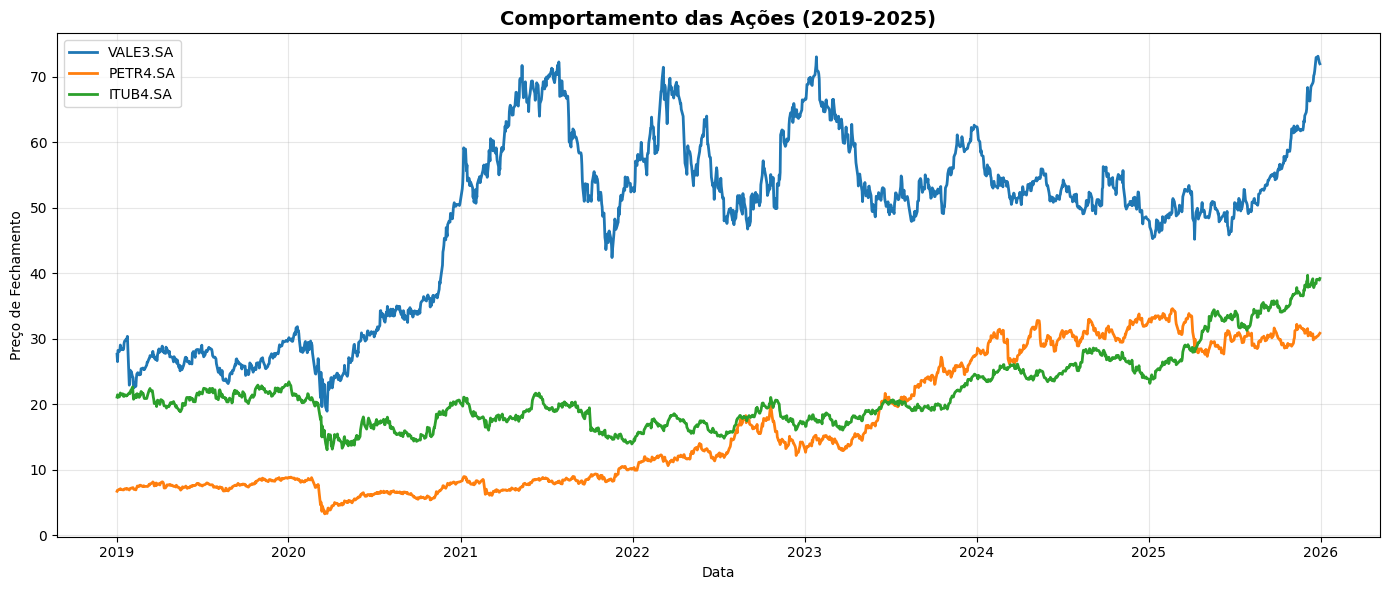

In [3]:
print("="*70)
print("BAIXANDO DADOS")
print("="*70)

tickers = ['VALE3.SA', 'PETR4.SA', 'ITUB4.SA']
dfs = []

for t in tickers:
    df = yf.download(t, start='2019-01-01', end='2025-12-31', progress=False)
    df = df[['Close']]
    df.columns = [t]
    dfs.append(df)

data = pd.concat(dfs, axis=1).dropna()

print(f"✓ Dados baixados: {data.shape}")
print(f"  Período: {data.index[0].date()} a {data.index[-1].date()}")
print(f"  Ações: {list(data.columns)}")
print(f"\nPrimeiras 5 linhas:")
print(data.head())

# Visualizar
plt.figure(figsize=(14, 6))
for col in data.columns:
    plt.plot(data.index, data[col], label=col, linewidth=2)
plt.title('Comportamento das Ações (2019-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Data')
plt.ylabel('Preço de Fechamento')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. CRIAR FEATURES E CLASSES

In [4]:
print("="*70)
print("PROCESSANDO FEATURES E CLASSES")
print("="*70)

def create_features_with_classes(series, n_features=4):
    """
    Cria features t1-t4 (valores anteriores) e target como classe:
    - Classe 0 (Short):  preço cai (delta < -0.5%)
    - Classe 1 (Neutro): preço estável (-0.5% <= delta <= 0.5%)
    - Classe 2 (Long):   preço sobe (delta > 0.5%)
    """
    df = pd.DataFrame()

    # Features: preços anteriores
    for i in range(1, n_features + 1):
        df[f't{i}'] = series.shift(i)

    # Target: variação percentual
    delta = series.pct_change() * 100  # em percentual

    # Classificar em 3 classes
    df['target'] = pd.cut(delta,
                          bins=[-np.inf, -0.5, 0.5, np.inf],
                          labels=[0, 1, 2])

    df = df.dropna()
    df['target'] = df['target'].astype(int)

    return df

# Usar VALE3 como exemplo
features = create_features_with_classes(data['VALE3.SA'], n_features=4)

print(f"\n✓ Features criadas:")
print(f"  Shape: {features.shape}")
print(f"\nDistribuição de classes:")
dist = features['target'].value_counts().sort_index()
for idx, count in dist.items():
    pct = count / len(features) * 100
    print(f"  Classe {idx}: {count:4d} amostras ({pct:5.1f}%)")

PROCESSANDO FEATURES E CLASSES

✓ Features criadas:
  Shape: (1738, 5)

Distribuição de classes:
  Classe 0:  627 amostras ( 36.1%)
  Classe 1:  465 amostras ( 26.8%)
  Classe 2:  646 amostras ( 37.2%)


## 3. SEPARAR TREINO E TESTE

In [5]:
# Separar por data
train_features = features.loc['2019':'2024']
test_features = features.loc['2025']

X_train = train_features[['t1', 't2', 't3', 't4']].values
y_train = train_features['target'].values

X_test = test_features[['t1', 't2', 't3', 't4']].values
y_test = test_features['target'].values

print(f"✓ Dados separados:")
print(f"  Treino: {X_train.shape[0]} amostras")
print(f"  Teste:  {X_test.shape[0]} amostras")
print(f"  Proporção: {X_train.shape[0]/(X_train.shape[0]+X_test.shape[0]):.1%} treino / {X_test.shape[0]/(X_train.shape[0]+X_test.shape[0]):.1%} teste")

✓ Dados separados:
  Treino: 1488 amostras
  Teste:  250 amostras
  Proporção: 85.6% treino / 14.4% teste


## 4. NORMALIZAR PARA [-1, 1]

In [6]:
scaler_X = MinMaxScaler(feature_range=(-1, 1))

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

print(f"✓ Dados normalizados para [-1, 1]")
print(f"  X_train: min={X_train_scaled.min():.3f}, max={X_train_scaled.max():.3f}")
print(f"  X_test:  min={X_test_scaled.min():.3f}, max={X_test_scaled.max():.3f}")

✓ Dados normalizados para [-1, 1]
  X_train: min=-1.000, max=1.000
  X_test:  min=-0.030, max=1.004


## 5. RESHAPE PARA LSTM

In [7]:
# LSTM espera: (n_samples, n_timesteps, n_features)
# Temos 4 timesteps (t1-t4) com 1 feature cada
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0],
                                        X_train_scaled.shape[1], 1))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0],
                                      X_test_scaled.shape[1], 1))

print(f"✓ Reshape para LSTM:")
print(f"  X_train_lstm: {X_train_lstm.shape}")
print(f"  X_test_lstm:  {X_test_lstm.shape}")
print(f"\n  Formato: (n_samples, n_timesteps, n_features)")
print(f"           ({X_train_lstm.shape[0]:5d},      {X_train_lstm.shape[1]},           {X_train_lstm.shape[2]})")

✓ Reshape para LSTM:
  X_train_lstm: (1488, 4, 1)
  X_test_lstm:  (250, 4, 1)

  Formato: (n_samples, n_timesteps, n_features)
           ( 1488,      4,           1)


## 6. CONSTRUIR MODELO LSTM COM SOFTMAX

In [8]:
print("="*70)
print("CONSTRUINDO MODELO LSTM")
print("="*70)

model = Sequential([
    # Primeira camada LSTM com 64 unidades
    LSTM(64,
         input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]),
         return_sequences=True,
         activation='relu'),
    Dropout(0.2),

    # Segunda camada LSTM com 32 unidades
    LSTM(32,
         activation='relu'),
    Dropout(0.2),

    # Camada densa para reduzir dimensionalidade
    Dense(16, activation='relu'),
    Dropout(0.1),

    # ⭐ CAMADA DE SAÍDA COM SOFTMAX PARA 3 CLASSES ⭐
    Dense(3, activation='softmax')  # 3 classes: Short, Neutro, Long
])

# Compilar modelo
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),  # ⭐ Para labels inteiros (0, 1, 2) ⭐
    metrics=['accuracy']
)

print("\n✓ Arquitetura do modelo:")
model.summary()

print("\n📊 Detalhes:")
print("""
  Camada 1: LSTM(64) + Dropout(0.2)
    Input shape:  (None, 4, 1)      # 4 timesteps, 1 feature
    Output shape: (None, 4, 64)     # return_sequences=True

  Camada 2: LSTM(32) + Dropout(0.2)
    Input:  (None, 4, 64)
    Output: (None, 32)              # return_sequences=False (padrão)

  Camada 3: Dense(16) + Dropout(0.1)
    Input:  (None, 32)
    Output: (None, 16)

  ⭐ Camada 4: Dense(3, softmax) ⭐
    Input:  (None, 16)
    Output: (None, 3) com PROBABILIDADES

    Softmax converte: [z0, z1, z2] → [P(Short), P(Neutro), P(Long)]
    Onde: P(Short) + P(Neutro) + P(Long) = 1.0
""")

CONSTRUINDO MODELO LSTM

✓ Arquitetura do modelo:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 4, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,891 (116.76 KB)

 Trainable params: 29,891 (116.76 KB)

 Non-trainable params: 0 (0.00 B)


📊 Detalhes:

  Camada 1: LSTM(64) + Dropout(0.2)
    Input shape:  (None, 4, 1)      # 4 timesteps, 1 feature
    Output shape: (None, 4, 64)     # return_sequences=True
    
  Camada 2: LSTM(32) + Dropout(0.2)
    Input:  (None, 4, 64)
    Output: (None, 32)              # return_sequences=False (padrão)
    
  Camada 3: Dense(16) + Dropout(0.1)
    Input:  (None, 32)
    Output: (None, 16)
    
  ⭐ Camada 4: Dense(3, softmax) ⭐
    Input:  (None, 16)
    Output: (None, 3) com PROBABILIDADES
    
    Softmax converte: [z0, z1, z2] → [P(Short), P(Neutro), P(Long)]
    Onde: P(Short) + P(Neutro) + P(Long) = 1.0



## 7. TREINAR MODELO

In [9]:
print("="*70)
print("TREINANDO MODELO")
print("="*70)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_lstm, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

print(f"\n✓ Treinamento concluído!")
print(f"  Epochs treinados: {len(history.history['loss'])}")
print(f"  Acurácia final (treino): {history.history['accuracy'][-1]:.4f}")
print(f"  Acurácia final (validação): {history.history['val_accuracy'][-1]:.4f}")

TREINANDO MODELO
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.3616 - loss: 1.0881 - val_accuracy: 0.2946 - val_loss: 1.1136
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3742 - loss: 1.0776 - val_accuracy: 0.3482 - val_loss: 1.1293
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.3861 - loss: 1.0747 - val_accuracy: 0.2946 - val_loss: 1.1388
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.3869 - loss: 1.0748 - val_accuracy: 0.3482 - val_loss: 1.1309
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.3940 - loss: 1.0730 - val_accuracy: 0.3884 - val_loss: 1.1460
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3924 - loss: 1.0732 - val_accuracy: 0.3929 - val_loss: 1.1422
Epoch 7/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4090 - loss: 1.0728 - val_accuracy: 0.3482 - val_loss: 1.1375
Epoch 8/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4019 - loss: 1.0736 -

## 8. FAZER PREVISÕES

In [10]:
print("="*70)
print("FAZENDO PREVISÕES")
print("="*70)

# Previsões em probabilidades (output do softmax)
y_pred_proba = model.predict(X_test_lstm, verbose=0)

# Classe com maior probabilidade
y_pred_class = np.argmax(y_pred_proba, axis=1)

# Mapeamento de classes
class_names = {0: 'Short Memory', 1: 'Neutro', 2: 'Long Memory'}

print(f"\n✓ Previsões geradas: {len(y_pred_class)}")

# Mostrar algumas previsões
print(f"\nPrimeiras 10 previsões com probabilidades:")
print("-" * 85)
print(f"{'Idx':<5} {'Real':<15} {'Previsto':<15} {'P(Short)':<10} {'P(Neutro)':<10} {'P(Long)':<10}")
print("-" * 85)
for i in range(min(10, len(y_pred_class))):
    real = class_names[y_test[i]]
    pred = class_names[y_pred_class[i]]
    p_short, p_neutro, p_long = y_pred_proba[i]
    print(f"{i:<5} {real:<15} {pred:<15} {p_short:>8.1%}  {p_neutro:>8.1%}  {p_long:>8.1%}")

FAZENDO PREVISÕES

✓ Previsões geradas: 250

Primeiras 10 previsões com probabilidades:
-------------------------------------------------------------------------------------
Idx   Real            Previsto        P(Short)   P(Neutro)  P(Long)   
-------------------------------------------------------------------------------------
0     Short Memory    Long Memory        35.7%     27.8%     36.5%
1     Short Memory    Long Memory        35.7%     27.8%     36.5%
2     Short Memory    Long Memory        35.7%     27.8%     36.5%
3     Short Memory    Long Memory        35.7%     27.8%     36.5%
4     Short Memory    Long Memory        35.7%     27.9%     36.5%
5     Short Memory    Long Memory        35.6%     27.9%     36.5%
6     Long Memory     Long Memory        35.6%     27.9%     36.5%
7     Neutro          Long Memory        35.6%     27.9%     36.5%
8     Long Memory     Long Memory        35.6%     27.9%     36.5%
9     Long Memory     Long Memory        35.6%     27.9%     36.5%

## 9. MÉTRICAS DE AVALIAÇÃO

In [11]:
print("="*70)
print("MÉTRICAS DE AVALIAÇÃO")
print("="*70)

accuracy = accuracy_score(y_test, y_pred_class)
print(f"\n✓ Acurácia Geral: {accuracy:.4f} ({accuracy*100:.2f}%)")

print(f"\n✓ Relatório de Classificação:")
print(classification_report(y_test, y_pred_class,
                          target_names=['Short', 'Neutro', 'Long']))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_class)
print(f"\n✓ Matriz de Confusão:")
print(f"           Predito_0  Predito_1  Predito_2")
for i, row in enumerate(cm):
    print(f"Real_{i}:   {row[0]:4d}      {row[1]:4d}      {row[2]:4d}")

MÉTRICAS DE AVALIAÇÃO

✓ Acurácia Geral: 0.3680 (36.80%)

✓ Relatório de Classificação:
              precision    recall  f1-score   support

       Short       0.00      0.00      0.00        63
      Neutro       0.00      0.00      0.00        95
        Long       0.37      1.00      0.54        92

    accuracy                           0.37       250
   macro avg       0.12      0.33      0.18       250
weighted avg       0.14      0.37      0.20       250


✓ Matriz de Confusão:
           Predito_0  Predito_1  Predito_2
Real_0:      0         0        63
Real_1:      0         0        95
Real_2:      0         0        92


## 10. VISUALIZAÇÕES

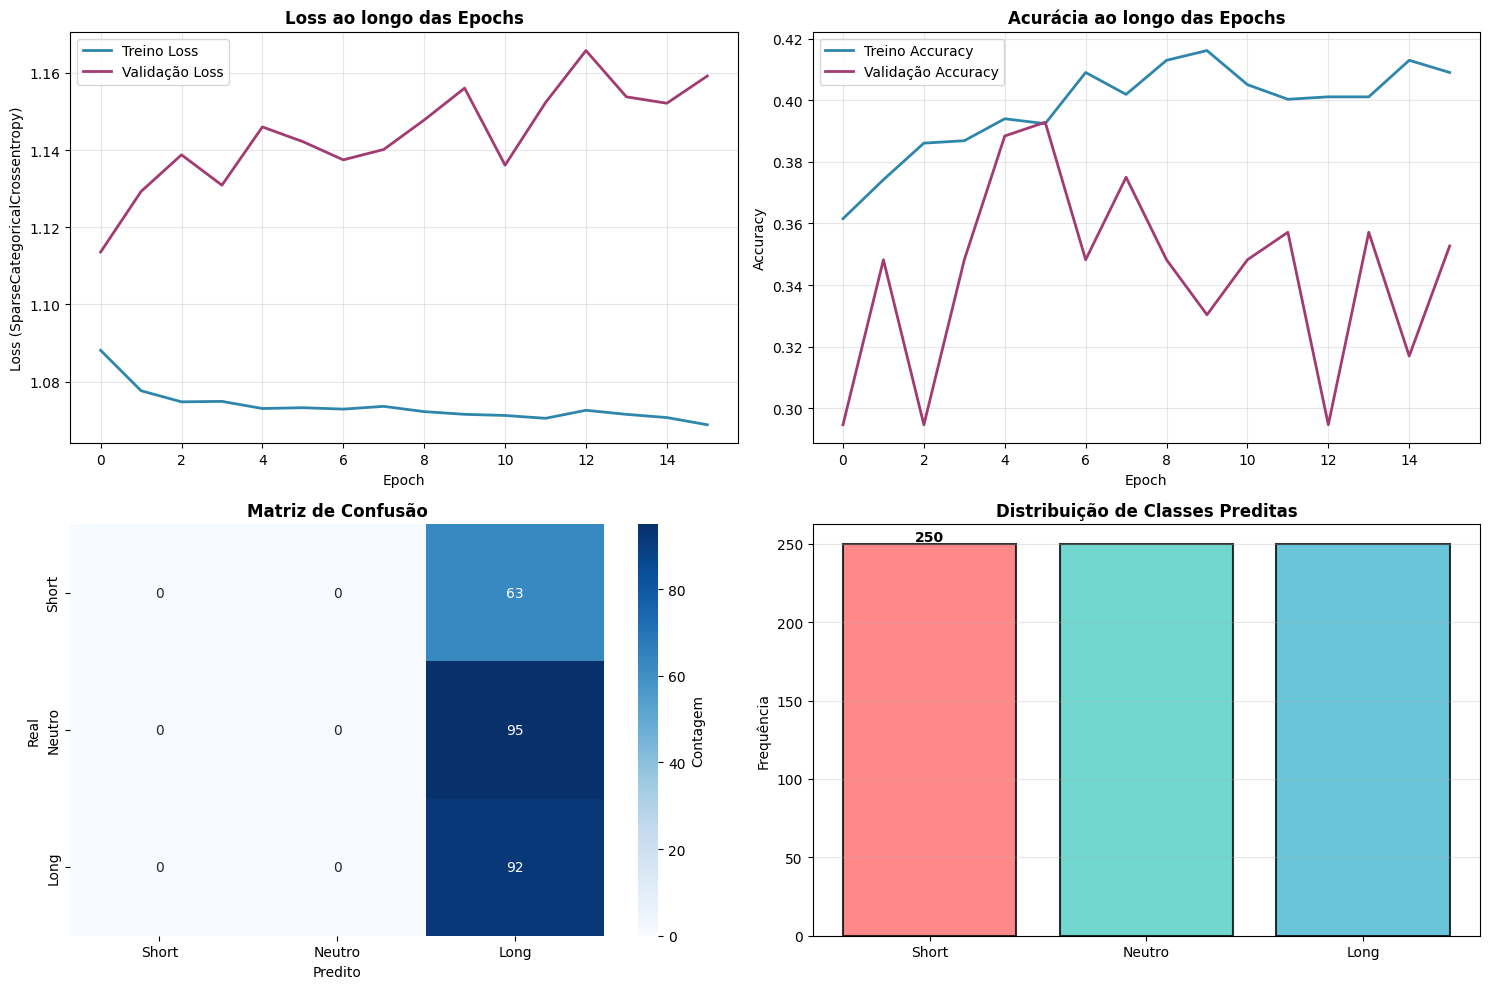

In [12]:
# Loss e Accuracy curves
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
ax = axes[0, 0]
ax.plot(history.history['loss'], label='Treino Loss', linewidth=2, color='#2E86AB')
ax.plot(history.history['val_loss'], label='Validação Loss', linewidth=2, color='#A23B72')
ax.set_title('Loss ao longo das Epochs', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (SparseCategoricalCrossentropy)')
ax.legend()
ax.grid(True, alpha=0.3)

# Accuracy
ax = axes[0, 1]
ax.plot(history.history['accuracy'], label='Treino Accuracy', linewidth=2, color='#2E86AB')
ax.plot(history.history['val_accuracy'], label='Validação Accuracy', linewidth=2, color='#A23B72')
ax.set_title('Acurácia ao longo das Epochs', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# Confusion Matrix
ax = axes[1, 0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Short', 'Neutro', 'Long'],
            yticklabels=['Short', 'Neutro', 'Long'],
            ax=ax, cbar_kws={'label': 'Contagem'})
ax.set_title('Matriz de Confusão', fontsize=12, fontweight='bold')
ax.set_ylabel('Real')
ax.set_xlabel('Predito')

# Distribuição de previsões
ax = axes[1, 1]
unique, counts = np.unique(y_pred_class, return_counts=True)
colors_bar = ['#ff6b6b', '#4ecdc4', '#45b7d1']
ax.bar(['Short', 'Neutro', 'Long'], counts, color=colors_bar, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_title('Distribuição de Classes Preditas', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequência')
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(counts):
    ax.text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

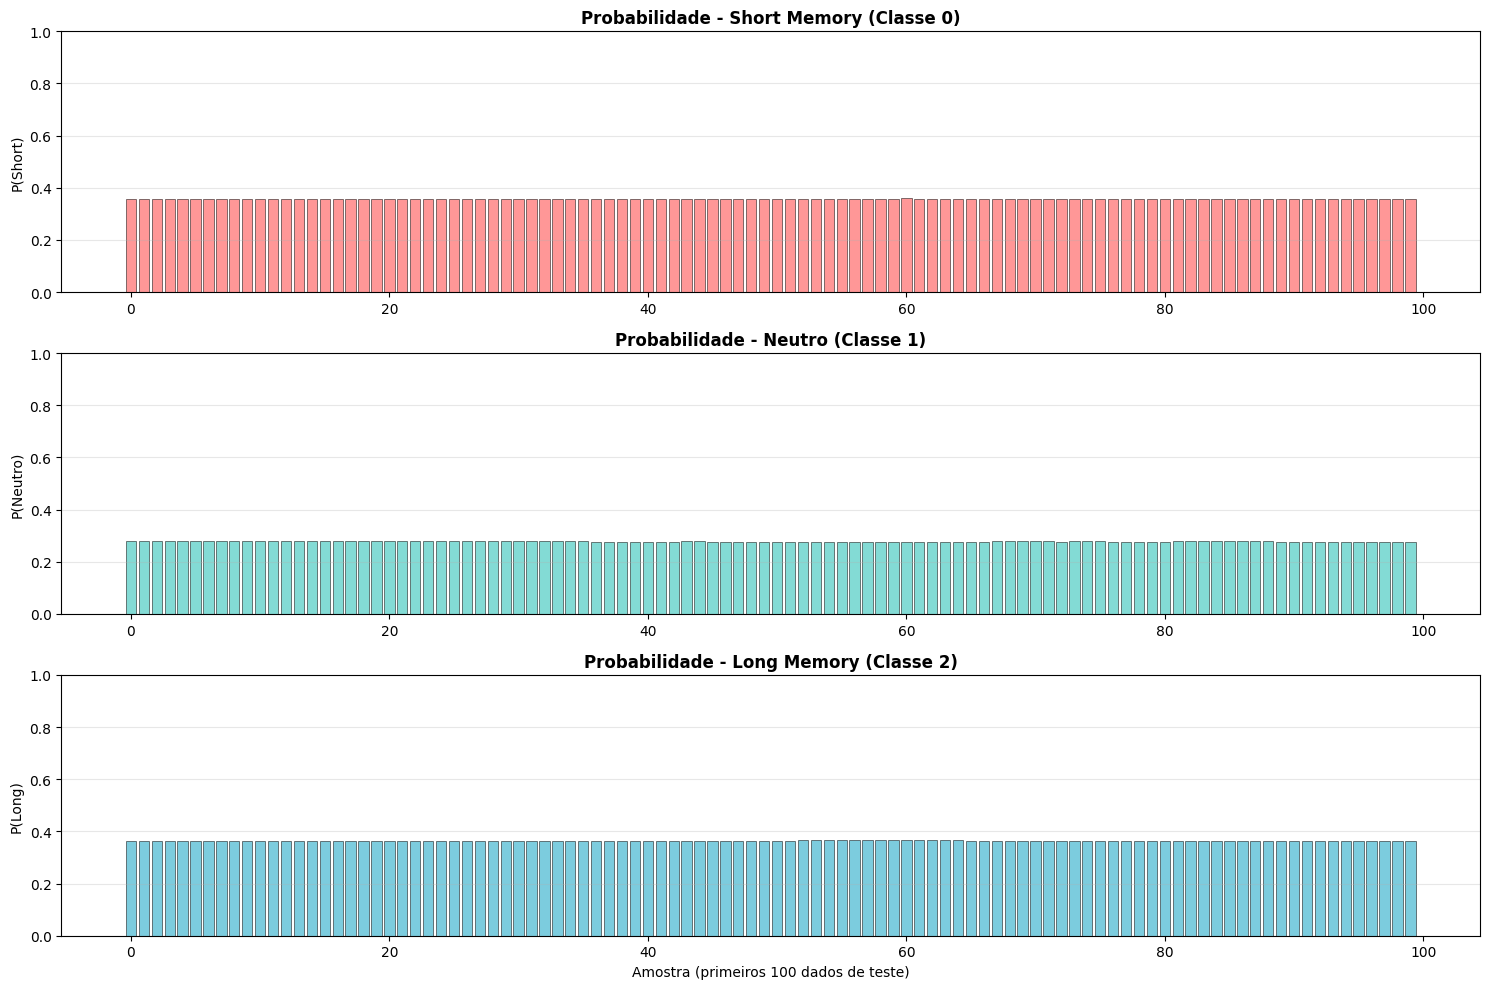

✓ Observe como Softmax distribui as probabilidades entre as 3 classes!


In [13]:
# Probabilidades por classe (Softmax)
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

n_show = min(100, len(y_test))

# Short Memory
ax = axes[0]
ax.bar(range(n_show), y_pred_proba[:n_show, 0], color='#ff6b6b', alpha=0.7, edgecolor='black', linewidth=0.5)
ax.set_title('Probabilidade - Short Memory (Classe 0)', fontsize=12, fontweight='bold')
ax.set_ylabel('P(Short)')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')

# Neutro
ax = axes[1]
ax.bar(range(n_show), y_pred_proba[:n_show, 1], color='#4ecdc4', alpha=0.7, edgecolor='black', linewidth=0.5)
ax.set_title('Probabilidade - Neutro (Classe 1)', fontsize=12, fontweight='bold')
ax.set_ylabel('P(Neutro)')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')

# Long Memory
ax = axes[2]
ax.bar(range(n_show), y_pred_proba[:n_show, 2], color='#45b7d1', alpha=0.7, edgecolor='black', linewidth=0.5)
ax.set_title('Probabilidade - Long Memory (Classe 2)', fontsize=12, fontweight='bold')
ax.set_ylabel('P(Long)')
ax.set_xlabel(f'Amostra (primeiros {n_show} dados de teste)')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Observe como Softmax distribui as probabilidades entre as 3 classes!")

✓ Análise de Confiança:
  Previsões com confiança > 70%: 0/250 (0.0%)
  Confiança média: 36.6%
  Confiança mínima: 36.5%
  Confiança máxima: 37.3%


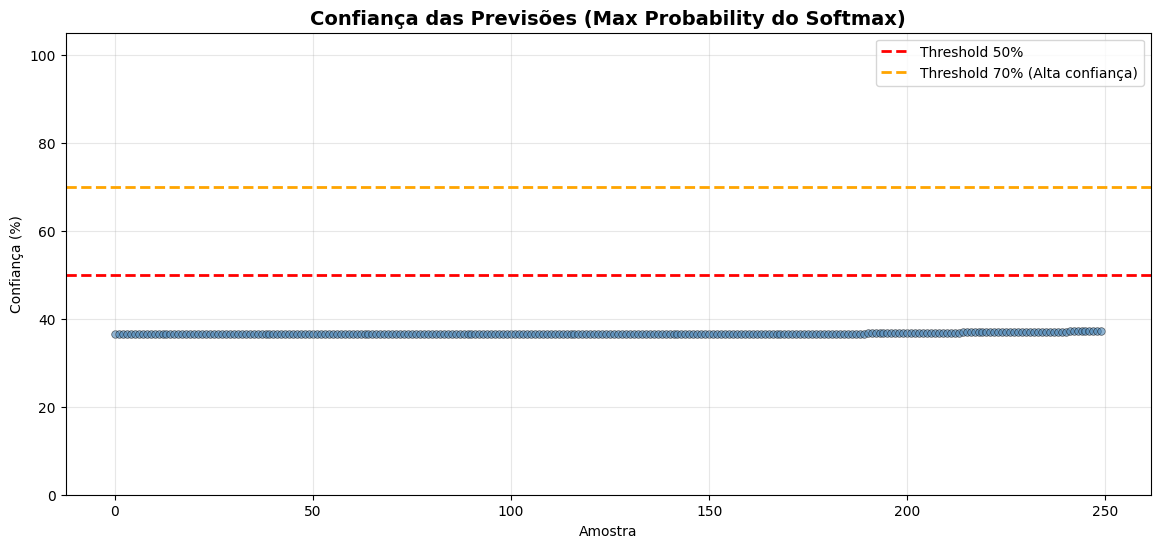

In [14]:
# Análise de Confiança
fig, ax = plt.subplots(figsize=(14, 6))

confidences = np.max(y_pred_proba, axis=1) * 100

ax.scatter(range(len(confidences)), confidences, alpha=0.6, s=30, color='steelblue', edgecolors='black', linewidth=0.5)
ax.axhline(y=50, color='red', linestyle='--', linewidth=2, label='Threshold 50%')
ax.axhline(y=70, color='orange', linestyle='--', linewidth=2, label='Threshold 70% (Alta confiança)')

ax.set_title('Confiança das Previsões (Max Probability do Softmax)', fontsize=14, fontweight='bold')
ax.set_xlabel('Amostra')
ax.set_ylabel('Confiança (%)')
ax.set_ylim([0, 105])
ax.legend()
ax.grid(True, alpha=0.3)

high_conf = np.sum(confidences >= 70)
print(f"✓ Análise de Confiança:")
print(f"  Previsões com confiança > 70%: {high_conf}/{len(confidences)} ({high_conf/len(confidences)*100:.1f}%)")
print(f"  Confiança média: {np.mean(confidences):.1f}%")
print(f"  Confiança mínima: {np.min(confidences):.1f}%")
print(f"  Confiança máxima: {np.max(confidences):.1f}%")

plt.show()

## 11. RESUMO FINAL

In [16]:
print("\n" + "="*70)
print("RESUMO FINAL - LSTM COM SOFTMAX")
print("="*70)

print(f"""
┌─────────────────────────────────────────────────────────────┐
│ ⭐ MODELO: LSTM com SOFTMAX para CLASSIFICAÇÃO em 3 CLASSES │
└─────────────────────────────────────────────────────────────┘

📊 ARQUITETURA:
  ├─ LSTM(64) com return_sequences=True → (None, 4, 64)
  │  └─ Aprende dependências temporais na sequência
  ├─ Dropout(0.2)
  ├─ LSTM(32) → (None, 32)
  │  └─ Processa padrões da LSTM anterior
  ├─ Dropout(0.2)
  ├─ Dense(16, relu) → (None, 16)
  │  └─ Reduz dimensionalidade
  ├─ Dropout(0.1)
  └─ ⭐ Dense(3, softmax) → (None, 3)
     └─ Softmax: converte em probabilidades (soma = 1)
        P(Short) + P(Neutro) + P(Long) = 1.0

⚙️ COMPILAÇÃO:
  ├─ Otimizador: Adam(learning_rate=0.001)
  └─ Loss: SparseCategoricalCrossentropy
     └─ Apropriado para classificação com labels inteiros

📈 TREINAMENTO:
  ├─ Epochs: {len(history.history['loss'])}
  ├─ Batch size: 16
  ├─ Validation split: 15%
  ├─ Early stopping: paciência 15
  ├─ Acurácia treino: {history.history['accuracy'][-1]:.2%}
  └─ Acurácia validação: {history.history['val_accuracy'][-1]:.2%}

📊 DADOS:
  ├─ Ação: VALE3.SA
  ├─ Período treino: 2019-2024 ({X_train.shape[0]} amostras)
  ├─ Período teste: 2025 ({X_test.shape[0]} amostras)
  ├─ Features: 4 preços anteriores (t1, t2, t3, t4)
  └─ Classes:
     ├─ 0 = Short Memory (↓ preço cai > 0.5%)
     ├─ 1 = Neutro (→ -0.5% ≤ variação ≤ 0.5%)
     └─ 2 = Long Memory (↑ preço sobe > 0.5%)

🎯 RESULTADOS:
  ├─ Acurácia geral: {accuracy:.2%}
  ├─ Previsões com confiança > 70%: {high_conf}/{len(confidences)} ({high_conf/len(confidences)*100:.1f}%)
  └─ Confiança média: {np.mean(confidences):.1f}%
""")

print("""
 (Classificação com Softmax):
   - Dense(3, softmax) → 3 probabilidades que somam 1.0
   - A rede APRENDE as 3 classes diretamente
   - Loss: SparseCategoricalCrossentropy (apropriado para classificação)
   - Softmax fornece confiança natural (probabilidade)
   - Muito melhor para este problema!
""")

print("="*70)
print("="*70)


RESUMO FINAL - LSTM COM SOFTMAX

┌─────────────────────────────────────────────────────────────┐
│ ⭐ MODELO: LSTM com SOFTMAX para CLASSIFICAÇÃO em 3 CLASSES │
└─────────────────────────────────────────────────────────────┘

📊 ARQUITETURA:
  ├─ LSTM(64) com return_sequences=True → (None, 4, 64)
  │  └─ Aprende dependências temporais na sequência
  ├─ Dropout(0.2)
  ├─ LSTM(32) → (None, 32)
  │  └─ Processa padrões da LSTM anterior
  ├─ Dropout(0.2)
  ├─ Dense(16, relu) → (None, 16)
  │  └─ Reduz dimensionalidade
  ├─ Dropout(0.1)
  └─ ⭐ Dense(3, softmax) → (None, 3)
     └─ Softmax: converte em probabilidades (soma = 1)
        P(Short) + P(Neutro) + P(Long) = 1.0

⚙️ COMPILAÇÃO:
  ├─ Otimizador: Adam(learning_rate=0.001)
  └─ Loss: SparseCategoricalCrossentropy
     └─ Apropriado para classificação com labels inteiros

📈 TREINAMENTO:
  ├─ Epochs: 16
  ├─ Batch size: 16
  ├─ Validation split: 15%
  ├─ Early stopping: paciência 15
  ├─ Acurácia treino: 40.90%
  └─ Acurácia validação: 3